# Plot H and H Growth Curves
March 6, 2024

Check the matrix H and the locations of DG1 with different alpha values

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.create_models_S import ModelCreation as ModelCreationS
from src.config import Config, read_yl_vst_data_rep
from cc_src.chromatin_model import ChromatinModel

def compute_scaling_term(chromatin_model, H):
    scaling_term = H.sum(axis=1)
    scaling_term /= scaling_term[0]
    df = pd.DataFrame(index=chromatin_model.timepoints, data={'scale':
        scaling_term})
    return df

def load_s_chromatin_model(replicate, alpha):
    posteriors_path = f'data/2019_cloccs_fits/yl_2019_replicate{replicate}/posteriors.txt'
    output_path = f'models/yl_cell_cycle/wt{replicate}_s_rg1.{alpha}.label'

    model_creator = ModelCreationS(posteriors_path, output_path)
    model_creator.alpha = alpha
    model_creator.create_model()

    config = Config(wt1=read_yl_vst_data_rep(replicate), model_wt1_file=output_path, 
                    name=f'Replicate {replicate} S, $\\alpha$={alpha}', 
                    replicate=replicate, alpha=alpha)

    chromatin_model = ChromatinModel(config)
    chromatin_model.load_mnase_gene("SEO1")
    chromatin_model.setup_deconv_model()
    chromatin_model.setup_deconv_model()
    return chromatin_model


In [3]:
chromatin_model2 = load_s_chromatin_model(replicate=2, alpha=22)
chromatin_model1 = load_s_chromatin_model(replicate=1, alpha=28)

Created model and saved to file: models/yl_cell_cycle/wt2_s_rg1.22.label
Loading MNase reads for YAL067C/SEO1...Loading chromosome reads: 1
Done.
Created model and saved to file: models/yl_cell_cycle/wt1_s_rg1.28.label
Loading MNase reads for YAL067C/SEO1...Loading chromosome reads: 1
Done.


Text(0.5, 0.98, 'Equal sample normalization')

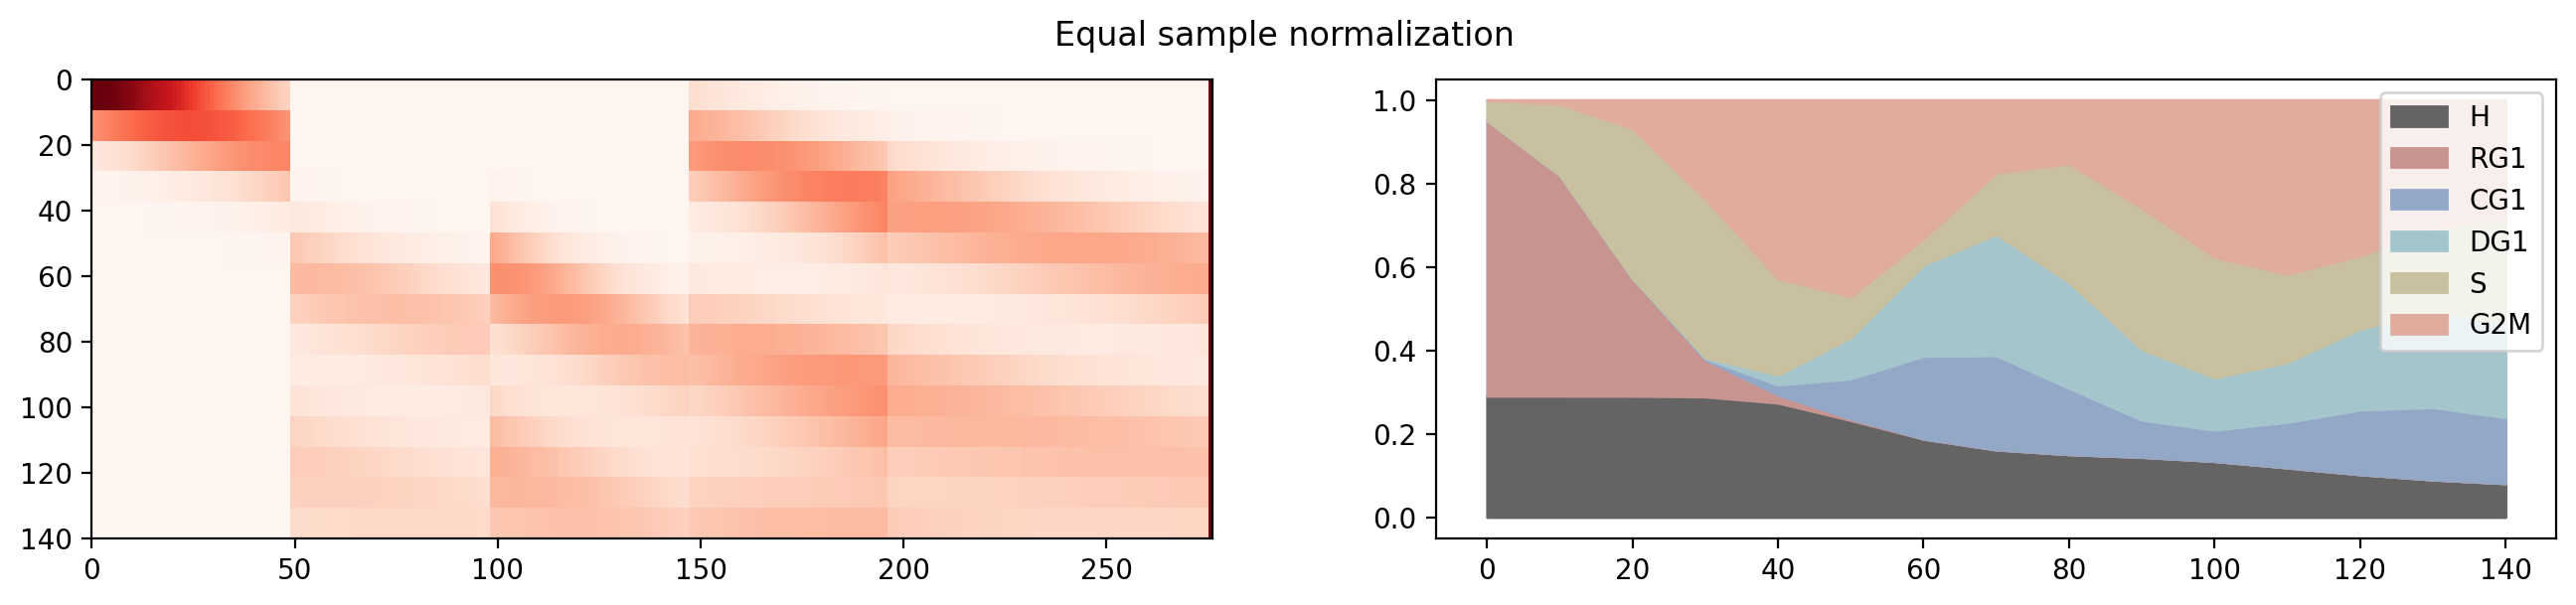

In [6]:
from src.estimate_dna_content import calcH_unnormalized

H, intervals = calcH_unnormalized(chromatin_model2.deconv_model.config, est_dna_content_mul=False, normalize_mass=True)
chromatin_model2.deconv_model.plot_H(H)
plt.suptitle("Equal sample normalization")

Text(0.5, 0.98, 'Cell population growth')

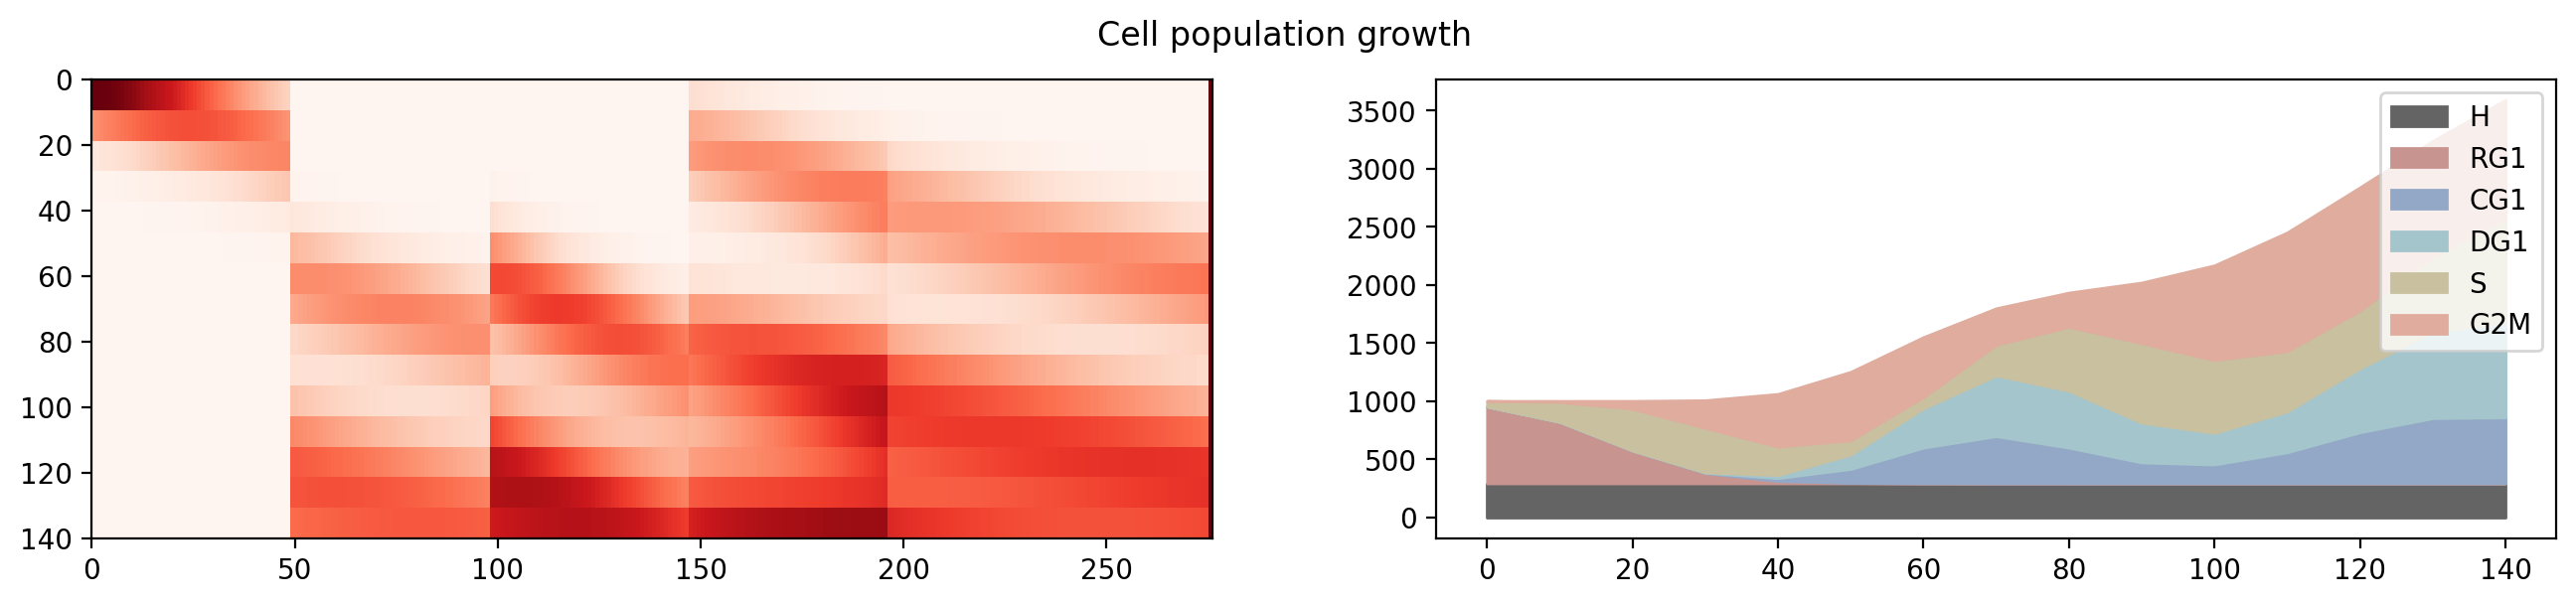

In [7]:
H, intervals = calcH_unnormalized(chromatin_model2.deconv_model.config,
                                  est_dna_content_mul=False, normalize_mass=False)
chromatin_model2.deconv_model.plot_H(H)
plt.suptitle("Cell population growth")

Text(0.5, 0.98, 'Population growth + DNA copy number')

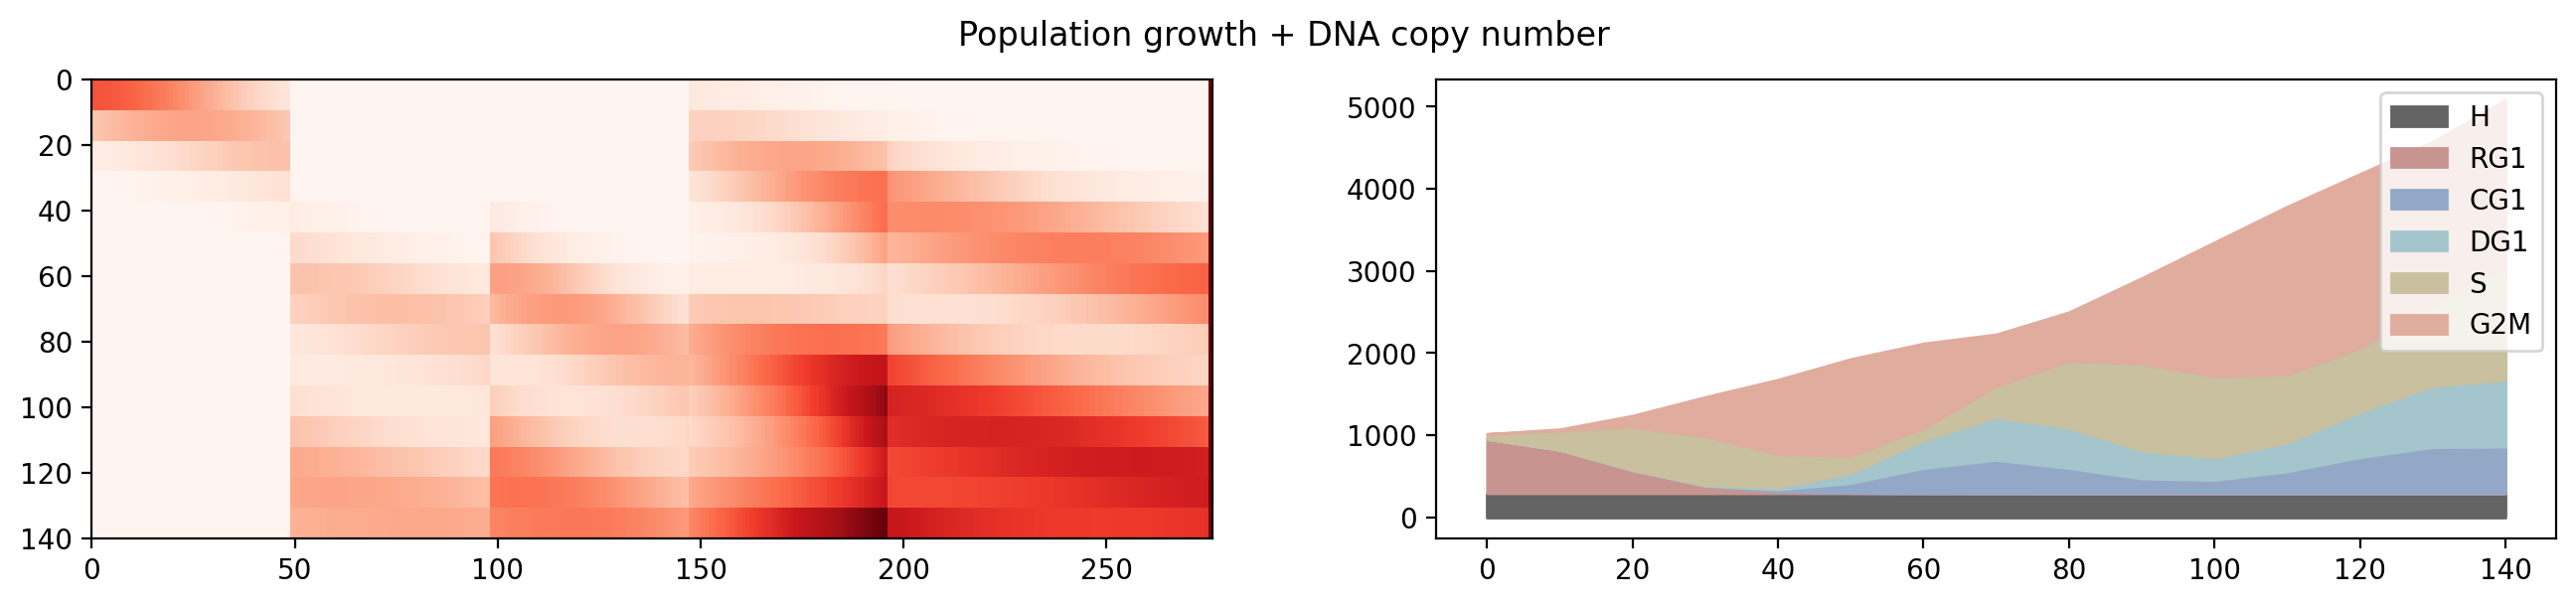

In [9]:
from src.estimate_dna_content import calcH_unnormalized

H_dna, intervals = calcH_unnormalized(chromatin_model2.deconv_model.config, est_dna_content_mul=True, normalize_mass=False)
chromatin_model2.deconv_model.plot_H(H_dna)
plt.suptitle("Population growth + DNA copy number")

## Normalizing based on DNA copy number only, remove cell population growth

Now, if we were to remove the growth in cell population and focus only on
the change in copy number, we can compute the average DNA content (copy number) for a cell
over time

Text(0.5, 0.98, 'Average DNA content over time, Replicate 2')

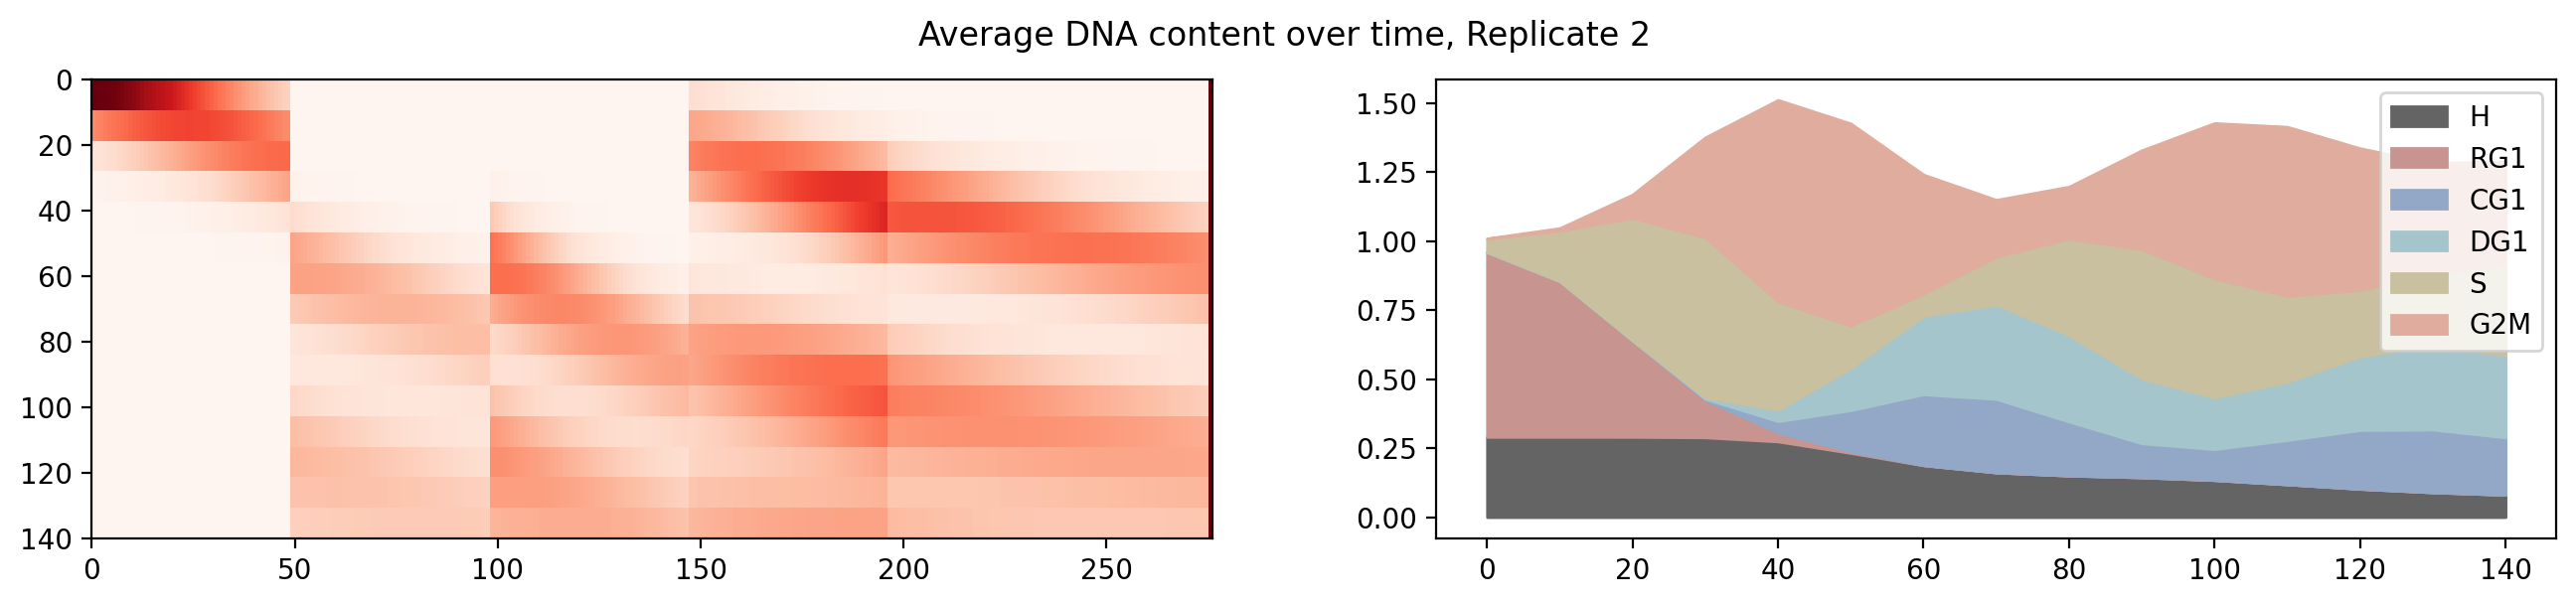

In [28]:
H_dna_content2, intervals = calcH_unnormalized(chromatin_model2.deconv_model.config, est_dna_content_mul=True, normalize_mass=True)
chromatin_model2.deconv_model.plot_H(H_dna_content2)
plt.suptitle(f"Average DNA content over time, Replicate {chromatin_model2.config.replicate}")


In [11]:
dna_content_scaling_replicate2 = compute_scaling_term(chromatin_model2, H_dna_content2)
dna_content_scaling_replicate2.head(2)

,scale
0,1.000000
10,1.056108


Text(0.5, 0.98, 'Average DNA content over time, Replicate 1')

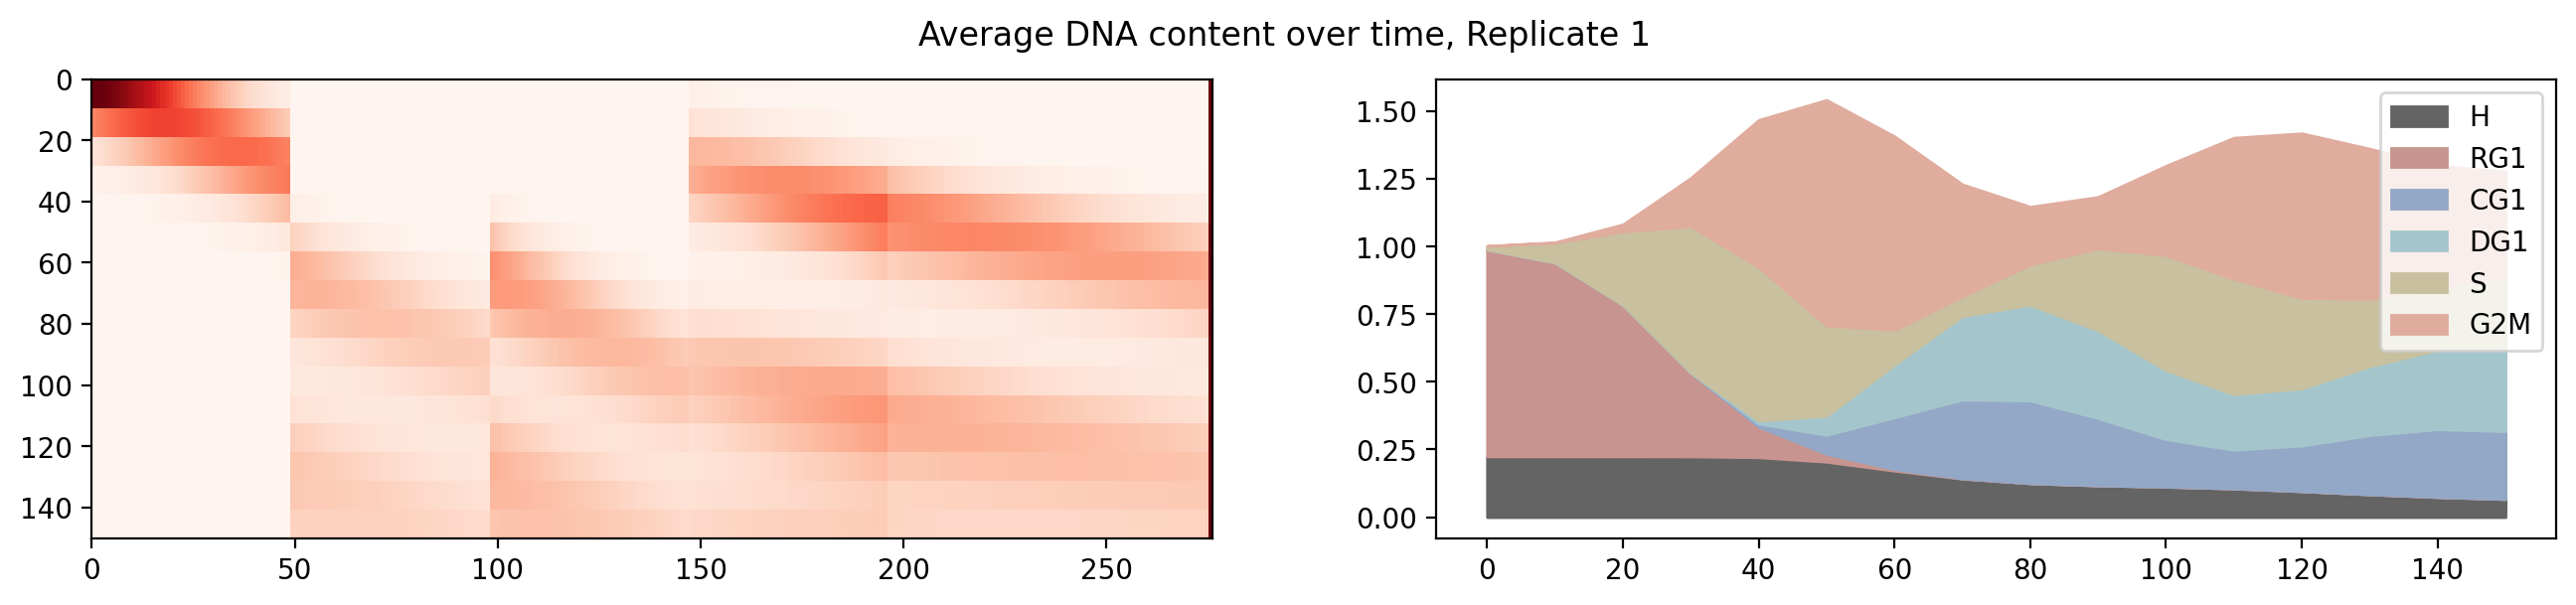

In [23]:
H_dna_content1, intervals = calcH_unnormalized(chromatin_model1.deconv_model.config, est_dna_content_mul=True, normalize_mass=True)
chromatin_model1.deconv_model.plot_H(H_dna_content1)
plt.suptitle(f"Average DNA content over time, Replicate {chromatin_model1.config.replicate}")

In [24]:
dna_content_scaling_replicate1 = compute_scaling_term(chromatin_model1, H_dna_content1)
dna_content_scaling_replicate1.head(2)

,scale
0,1.000000
10,1.013533


In [25]:
# Save to disk
dna_content_scaling_replicate2.to_csv('datasets/computed_mnase/dna_copy_scaling_rep2.csv')
dna_content_scaling_replicate1.to_csv('datasets/computed_mnase/dna_copy_scaling_rep1.csv')